In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
hyperdata = {"preprocessing": {}, "complexity": {}, "evaluation": {}}

In [3]:
row_order = [
    "CIC_IDS_2017",
    "CIC_IOT_Dataset2023",
    "IoT_23",
    "IoT_Network_Intrusion_Macro",
    "IoT_Network_Intrusion_Micro",
    "KDD_Cup_1999",
    "UNSW_NB15",
    "BCCC_CIC-BCCC-NRC-ACI-IOT-2023",
    "BCCC_CIC-BCCC-NRC-Edge-IIoTSet-2022",
    "BCCC_CIC-BCCC-NRC-IoMT-2024",
    "BCCC_CIC-BCCC-NRC-IoT-2022",
    "BCCC_CIC-BCCC-NRC-IoT-2023-Original_Training_and_Testing",
    "BCCC_CIC-BCCC-NRC-IoT-HCRL-2019",
    "BCCC_CIC-BCCC-NRC-MQTTIoT-IDS-2020",
    "BCCC_CIC-BCCC-NRC-TONIoT-2021",
    "BCCC_CIC-BCCC-NRC-UQ-IOT-2022",
    "BoT_IoT_Macro",
    "BoT_IoT_Micro",
    "CICAPT_IIoT_Phase1_Macro", # nok (single-class)
    "CICAPT_IIoT_Phase1_Micro", # nok (single-class)
    "CICAPT_IIoT_Phase2_Macro",
    "CICAPT_IIoT_Phase2_Micro",
    "CICEVSE2024_EVSE-A_Macro",
    "CICEVSE2024_EVSE-A_Micro",
    "CICEVSE2024_EVSE-B_Macro",
    "CICEVSE2024_EVSE-B_Micro",
    "CICIoMT2024_Bluetooth",
    "CICIoMT2024_WiFi_and_MQTT",
    "CICIoV2024_Decimal_Macro",
    "CICIoV2024_Decimal_Micro",
    "EDGE-IIOTSET_DNN-EdgeIIoT",
    "EDGE-IIOTSET_ML-EdgeIIoT",
    "MQTT_IoT_IDS2020_BiflowFeatures",
    "MQTT_IoT_IDS2020_PacketFeatures",
    "MQTT_IoT_IDS2020_UniflowFeatures",
    "NIDS_CIC-BoT-IoT",
    "NIDS_CIC-ToN-IoT",
    "NIDS_NF-BoT-IoT",
    "NIDS_NF-BoT-IoT-v2",
    "NIDS_NF-BoT-IoT-v3",
    "NIDS_NF-CICIDS2018-v3",
    "NIDS_NF-CSE-CIC-IDS2018",
    "NIDS_NF-CSE-CIC-IDS2018-v2",
    "NIDS_NF-ToN-IoT",
    "NIDS_NF-ToN-IoT-v2",
    "NIDS_NF-ToN-IoT-v3",
    "NIDS_NF-UNSW-NB15",
    "NIDS_NF-UNSW-NB15-v2",
    "NIDS_NF-UNSW-NB15-v3",
    "NIDS_NF-UQ-NIDS",
    "NIDS_NF-UQ-NIDS-v2",
    "N_BaIoT_Danmini_Doorbell",
    "N_BaIoT_Ecobee_Thermostat",
    "N_BaIoT_Ennio_Doorbell",
    "N_BaIoT_Philips_B120N10_Baby_Monitor",
    "N_BaIoT_Provision_PT_737E_Security_Camera",
    "N_BaIoT_Provision_PT_838_Security_Camera",
    "N_BaIoT_Samsung_SNH_1011_N_Webcam",
    "N_BaIoT_SimpleHome_XCS7_1002_WHT_Security_Camera",
    "N_BaIoT_SimpleHome_XCS7_1003_WHT_Security_Camera",
    "ToN_IoT_IoT_Fridge",
    "ToN_IoT_IoT_GPS_Tracker",
    "ToN_IoT_IoT_Garage_Door",
    "ToN_IoT_IoT_Modbus",
    "ToN_IoT_IoT_Motion_Light",
    "ToN_IoT_IoT_Thermostat",
    "ToN_IoT_IoT_Weather",
    "ToN_IoT_Linux_Disk",
    "ToN_IoT_Linux_Memory",
    "ToN_IoT_Linux_Process",
    "ToN_IoT_Network",
    "ToN_IoT_Windows_10",
    "ToN_IoT_Windows_7"
]

# 1. Phase 1: Preprocessing

In [4]:
PREPROCESSING_ROOT_DIR = "../../2025-11-17/Input_Zip_v4"

In [5]:
def get_shapes(frac, shapes_dict):
    suffix = 'full' if frac == 'full' else 'sampled'
    ans = {}
    ans["n_rows_train"] = shapes_dict[f'train_{suffix}'][0]
    ans["n_rows_val"] = shapes_dict[f'val_{suffix}'][0]
    ans["n_rows_test"] = shapes_dict[f'test_{suffix}'][0]
    ans["n_rows_total"] = ans["n_rows_train"] + ans["n_rows_val"] + ans["n_rows_test"]
    assert shapes_dict[f'train_{suffix}'][1] == shapes_dict[f'val_{suffix}'][1], "2"
    assert shapes_dict[f'train_{suffix}'][1] == shapes_dict[f'test_{suffix}'][1], "3"
    assert shapes_dict[f'val_{suffix}'][1] == shapes_dict[f'test_{suffix}'][1], "4"
    ans["n_cols"] = shapes_dict[f'train_{suffix}'][1]
    ans["n_cells_train"] = ans["n_rows_train"] * ans["n_cols"]
    ans["n_cells_val"] = ans["n_rows_val"] * ans["n_cols"]
    ans["n_cells_test"] = ans["n_rows_test"] * ans["n_cols"]
    ans["n_cells_total"] = ans["n_rows_total"] * ans["n_cols"]
    return ans

In [6]:
for dataset_id in os.listdir(PREPROCESSING_ROOT_DIR):
    if dataset_id not in hyperdata:
        hyperdata["preprocessing"][dataset_id] = {}
    seed_parent_folder = os.path.join(PREPROCESSING_ROOT_DIR, dataset_id, 'Multiclass')
    for seed in os.listdir(seed_parent_folder):
        frac_parent_folder = os.path.join(seed_parent_folder, seed)
        for frac in os.listdir(frac_parent_folder):
            frac_full_folder = os.path.join(frac_parent_folder, frac)
            if frac not in hyperdata["preprocessing"][dataset_id]:
                hyperdata["preprocessing"][dataset_id][frac] = {}
            if seed not in hyperdata["preprocessing"][dataset_id][frac]:
                hyperdata["preprocessing"][dataset_id][frac][seed] = {}
            json_filename = os.path.join(frac_full_folder, f'{dataset_id}.metadata.json')
            with open(json_filename, 'r', encoding='utf-8') as f:
                metadata = json.load(f)
            hyperdata["preprocessing"][dataset_id][frac][seed] = metadata['execution_stats']
            hyperdata["preprocessing"][dataset_id][frac][seed]['shapes'] = get_shapes(frac, metadata['shapes'])

In [7]:
hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]

{'n_rows_train': 644998,
 'n_rows_val': 214997,
 'n_rows_test': 214997,
 'n_rows_total': 1074992,
 'n_cols': 41,
 'n_cells_train': 26444918,
 'n_cells_val': 8814877,
 'n_cells_test': 8814877,
 'n_cells_total': 44074672}

In [8]:
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_rows_train"] == 644998
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_rows_val"] == 214997
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_rows_test"] == 214997
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_rows_total"] == (644998 + 214997 + 214997)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_cols"] == 41
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_cells_train"] == ((644998) * 41)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_cells_val"] == ((214997) * 41)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_cells_test"] == ((214997) * 41)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["full"]["seed_17"]["shapes"]["n_cells_total"] == ((644998 + 214997 + 214997) * 41)

assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_rows_train"] == 32250
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_rows_val"] == 214997
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_rows_test"] == 214997
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_rows_total"] == (32250 + 214997 + 214997)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_cols"] == 41
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_cells_train"] == ((32250) * 41)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_cells_val"] == ((214997) * 41)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_cells_test"] == ((214997) * 41)
assert hyperdata["preprocessing"]["KDD_Cup_1999"]["sampled_05"]["seed_17"]["shapes"]["n_cells_total"] == ((32250 + 214997 + 214997) * 41)

In [9]:
preprocessing_rows = []
for dataset_id, fracs in hyperdata["preprocessing"].items():
    for frac_id, seeds in fracs.items():
        for seed_id, stages in seeds.items():
            # 1. Initialize the row with metadata
            row = {
                'dataset': dataset_id,
                'fraction': frac_id,
                'seed': seed_id
            }
            
            # 2. Iterate through stages (e.g., loading_and_sampling, profiling)
            for stage_name, stage_metrics in stages.items():
                # 3. Iterate through metrics (e.g., duration_sec, ram_peak_mb)
                for metric_name, metric_value in stage_metrics.items():
                    # Define the column name inside this loop
                    col_name = f"{stage_name}__{metric_name}"
                    # 4. Assign the value to the row
                    row[col_name] = metric_value
                    # if 'KDD' in dataset_id or '2017' in dataset_id or 'Intrusion' in dataset_id:
                    preprocessing_rows.append(row)

            # 5. Append the completed row to the list

# 6. Create the DataFrame
preprocessing_df = pd.DataFrame(preprocessing_rows)
preprocessing_df

,dataset,fraction,seed,loading_and_sampling__duration_sec,loading_and_sampling__cpu_raw_peak,loading_and_sampling__cpu_raw_avg,loading_and_sampling__cpu_norm_peak,loading_and_sampling__cpu_norm_avg,loading_and_sampling__ram_peak_mb,loading_and_sampling__ram_avg_mb,...,splitting__cpu_raw_peak,splitting__cpu_raw_avg,splitting__cpu_norm_peak,splitting__cpu_norm_avg,splitting__ram_peak_mb,splitting__ram_avg_mb,splitting__vram_peak_mb,splitting__vram_avg_mb,splitting__gpu_util_peak,splitting__gpu_util_avg
0,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BoT_IoT_Macro,sampled_05,seed_53,0.10,0.0,0.0,0.0,0.0,5494.94,5494.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95990,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95991,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95992,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95993,ToN_IoT_IoT_Garage_Door,sampled_20,seed_17,0.01,0.0,0.0,0.0,0.0,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
preprocessing_df.columns

Index(['dataset', 'fraction', 'seed', 'loading_and_sampling__duration_sec',
       'loading_and_sampling__cpu_raw_peak',
       'loading_and_sampling__cpu_raw_avg',
       'loading_and_sampling__cpu_norm_peak',
       'loading_and_sampling__cpu_norm_avg',
       'loading_and_sampling__ram_peak_mb', 'loading_and_sampling__ram_avg_mb',
       'loading_and_sampling__vram_peak_mb',
       'loading_and_sampling__vram_avg_mb',
       'loading_and_sampling__gpu_util_peak',
       'loading_and_sampling__gpu_util_avg', 'transformation__duration_sec',
       'transformation__cpu_raw_peak', 'transformation__cpu_raw_avg',
       'transformation__cpu_norm_peak', 'transformation__cpu_norm_avg',
       'transformation__ram_peak_mb', 'transformation__ram_avg_mb',
       'transformation__vram_peak_mb', 'transformation__vram_avg_mb',
       'transformation__gpu_util_peak', 'transformation__gpu_util_avg',
       'profiling__duration_sec', 'profiling__cpu_raw_peak',
       'profiling__cpu_raw_avg', 'profi

In [11]:
# 1. Rename the existing column
preprocessing_df = preprocessing_df.rename(columns={'dataset': 'dataset_name'})

# 2. Convert to Categorical to ensure the sort follows your row_order
preprocessing_df['dataset_name'] = pd.Categorical(preprocessing_df['dataset_name'], categories=row_order, ordered=True)

# 3. Create the dataset_id column based on the index in row_order
# We map the name to its index in the list
name_to_id = {name: i + 1 for i, name in enumerate(row_order)}
preprocessing_df['dataset_id'] = preprocessing_df['dataset_name'].map(name_to_id)

# 4. Sort and reorder columns so IDs and Names are at the front
preprocessing_df = preprocessing_df.sort_values(by=['dataset_id', 'fraction', 'seed']).reset_index(drop=True)

# Move dataset_id and dataset_name to the first and second positions
cols = ['dataset_id', 'dataset_name'] + [c for c in preprocessing_df.columns if c not in ['dataset_id', 'dataset_name']]
preprocessing_df = preprocessing_df[cols]

In [12]:
# 1. Calculate Total Peak RAM across all stages
ram_cols = [c for c in preprocessing_df.columns if '__ram_peak_mb' in c]
preprocessing_df['total_ram_peak_mb'] = preprocessing_df[ram_cols].max(axis=1)

# 2. Calculate Total Duration
duration_cols = [c for c in preprocessing_df.columns if '__duration_sec' in c]
preprocessing_df['total_duration_sec'] = preprocessing_df[duration_cols].sum(axis=1)

# 3. Calculate Average CPU Peak (or Max Peak)
cpu_cols = [c for c in preprocessing_df.columns if '__cpu_raw_peak' in c]
preprocessing_df['total_cpu_peak_max'] = preprocessing_df[cpu_cols].max(axis=1)

In [13]:
preprocessing_df

,dataset_id,dataset_name,fraction,seed,loading_and_sampling__duration_sec,loading_and_sampling__cpu_raw_peak,loading_and_sampling__cpu_raw_avg,loading_and_sampling__cpu_norm_peak,loading_and_sampling__cpu_norm_avg,loading_and_sampling__ram_peak_mb,...,splitting__cpu_norm_avg,splitting__ram_peak_mb,splitting__ram_avg_mb,splitting__vram_peak_mb,splitting__vram_avg_mb,splitting__gpu_util_peak,splitting__gpu_util_avg,total_ram_peak_mb,total_duration_sec,total_cpu_peak_max
0,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
1,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
2,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
3,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
4,1,CIC_IDS_2017,full,seed_17,NaN,NaN,NaN,NaN,NaN,NaN,...,3.3,9483.98,8113.38,488.81,488.81,0.0,0.0,11614.98,81.26,1025.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95990,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4
95991,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4
95992,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4
95993,NaN,NaN,sampled_50,seed_89,0.01,0.0,0.0,0.0,0.0,3709.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3709.34,0.81,65.4


/tmp/ipykernel_23756/3654977610.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


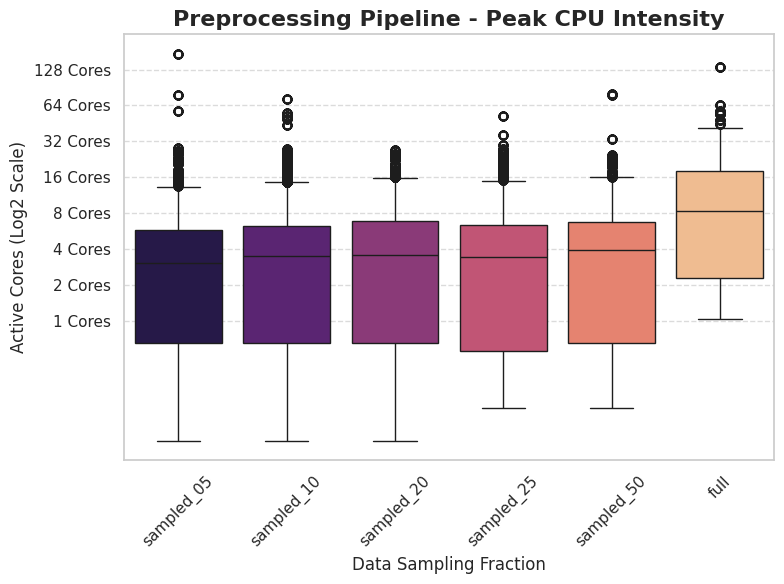

Generated phase_1_preprocessing_cpu.pdf


/tmp/ipykernel_23756/3654977610.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


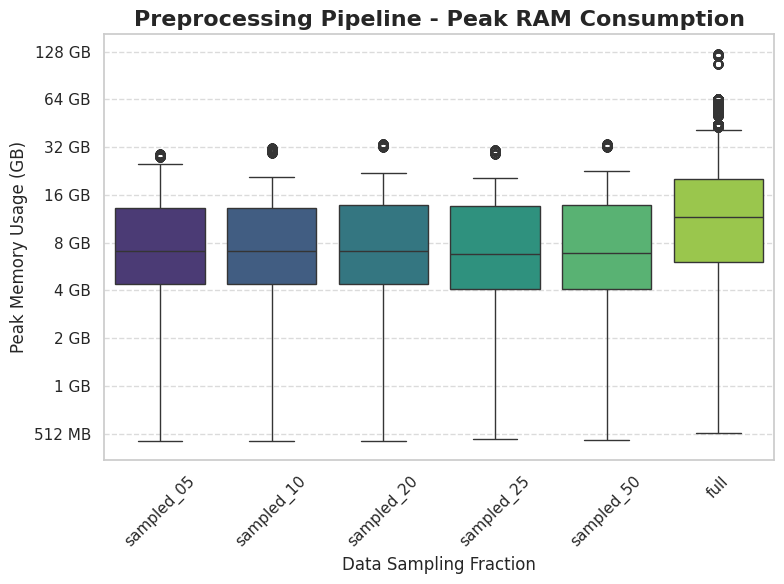

Generated phase_1_preprocessing_ram.pdf


/tmp/ipykernel_23756/3654977610.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


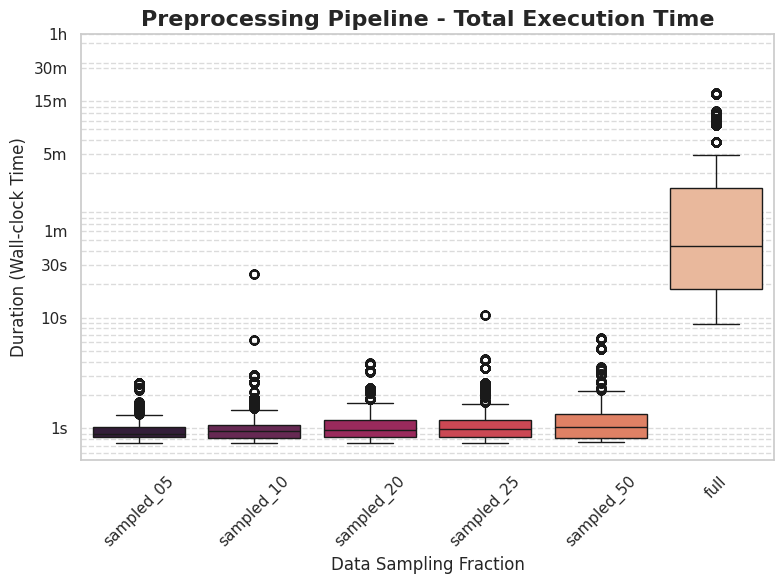

Generated phase_1_preprocessing_time.pdf


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the logical order for fractions
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

# --- 1. Define Configurations for each plot ---
# We store all the specific customizations (ticks, labels, palettes) in a list
plot_configs = [
    {
        'col': 'total_cpu_peak_max',
        'title': "Preprocessing Pipeline - Peak CPU Intensity",
        'ylabel': "Active Cores (Log2 Scale)",
        'palette': "magma",
        'scale_base': 2,
        'ticks': [c * 100 for c in [1, 2, 4, 8, 16, 32, 64, 128]],
        'tick_labels': [f'{c} Cores' for c in [1, 2, 4, 8, 16, 32, 64, 128]],
        'filename': 'phase_1_preprocessing_cpu'
    },
    {
        'col': 'total_ram_peak_mb',
        'title': "Preprocessing Pipeline - Peak RAM Consumption",
        'ylabel': "Peak Memory Usage (GB)",
        'palette': "viridis",
        'scale_base': 2,
        'ticks': [g * 1024 for g in [0.5, 1, 2, 4, 8, 16, 32, 64, 128]],
        'tick_labels': [f'{g} GB' if g >= 1 else f'{int(g*1024)} MB' for g in [0.5, 1, 2, 4, 8, 16, 32, 64, 128]],
        'filename': 'phase_1_preprocessing_ram'
    },
    {
        'col': 'total_duration_sec',
        'title': "Preprocessing Pipeline - Total Execution Time",
        'ylabel': "Duration (Wall-clock Time)",
        'palette': "rocket",
        'scale_base': 10,
        'ticks': [1, 10, 30, 60, 300, 900, 1800, 3600],
        'tick_labels': ['1s', '10s', '30s', '1m', '5m', '15m', '30m', '1h'],
        'filename': 'phase_1_preprocessing_time'
    }
]

sns.set_theme(style="whitegrid")

# --- 2. Generation Loop ---
for config in plot_configs:
    
    # Create a new individual figure
    plt.figure(figsize=(8, 6))
    
    # Plotting
    ax = sns.boxplot(
        data=preprocessing_df, 
        x='fraction', 
        y=config['col'], 
        order=fraction_order, 
        palette=config['palette']
    )
    
    # --- Custom Scales & Ticks ---
    ax.set_yscale('log', base=config['scale_base'])
    ax.set_yticks(config['ticks'])
    ax.set_yticklabels(config['tick_labels'])
    
    # --- Formatting ---
    ax.set_title(config['title'], fontsize=16, fontweight='bold')
    ax.set_ylabel(config['ylabel'], fontsize=12)
    ax.set_xlabel("Data Sampling Fraction", fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # Save individually
    full_filename = f"{config['filename']}.pdf"
    plt.savefig(full_filename, dpi=300)
    plt.show()
    plt.close()
    
    print(f"Generated {full_filename}")

In [15]:
# 1. Ensure fractions are in the correct logical order
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

# 2. Group by fraction and calculate medians
summary_table = preprocessing_df.groupby('fraction').agg({
    'total_ram_peak_mb': 'median',
    'total_cpu_peak_max': 'median',
    'total_duration_sec': 'median'
}).reindex(fraction_order).reset_index()

# 3. Convert to human-readable units (GB and Cores)
summary_table['Median RAM (GB)'] = (summary_table['total_ram_peak_mb'] / 1024).round(2)
summary_table['Median CPU (Cores)'] = (summary_table['total_cpu_peak_max'] / 100).round(1)
summary_table['Median Time (sec)'] = summary_table['total_duration_sec'].round(2)

# 4. Calculate Efficiency (Time saved vs Full)
full_time = summary_table.loc[summary_table['fraction'] == 'full', 'Median Time (sec)'].values[0]
summary_table['Speedup (x)'] = (full_time / summary_table['Median Time (sec)']).round(1)

# Display the final summary
display(summary_table[['fraction', 'Median RAM (GB)', 'Median CPU (Cores)', 'Median Time (sec)', 'Speedup (x)']])

,fraction,Median RAM (GB),Median CPU (Cores),Median Time (sec),Speedup (x)
0,sampled_05,7.10,3.1,0.90,48.9
1,sampled_10,7.11,3.5,0.94,46.8
2,sampled_20,7.11,3.6,0.97,45.4
3,sampled_25,6.75,3.4,0.98,44.9
4,sampled_50,6.83,3.9,1.04,42.3
5,full,11.61,8.3,44.00,1.0


In [16]:
preprocessing_df[preprocessing_df['fraction'] == 'full'].copy().columns

Index(['dataset_id', 'dataset_name', 'fraction', 'seed',
       'loading_and_sampling__duration_sec',
       'loading_and_sampling__cpu_raw_peak',
       'loading_and_sampling__cpu_raw_avg',
       'loading_and_sampling__cpu_norm_peak',
       'loading_and_sampling__cpu_norm_avg',
       'loading_and_sampling__ram_peak_mb', 'loading_and_sampling__ram_avg_mb',
       'loading_and_sampling__vram_peak_mb',
       'loading_and_sampling__vram_avg_mb',
       'loading_and_sampling__gpu_util_peak',
       'loading_and_sampling__gpu_util_avg', 'transformation__duration_sec',
       'transformation__cpu_raw_peak', 'transformation__cpu_raw_avg',
       'transformation__cpu_norm_peak', 'transformation__cpu_norm_avg',
       'transformation__ram_peak_mb', 'transformation__ram_avg_mb',
       'transformation__vram_peak_mb', 'transformation__vram_avg_mb',
       'transformation__gpu_util_peak', 'transformation__gpu_util_avg',
       'profiling__duration_sec', 'profiling__cpu_raw_peak',
       'profi

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d
import os

def calculate_bic(n, rss, k):
    if n <= k + 1 or rss <= 0: return np.inf
    return n * np.log(rss / n) + k * np.log(n)

def plot_scalability_individual_files(df, phase, duration_col):
    print("--- Generating Individual Scalability Plots (PNG & PDF) ---")
    
    target_col = 'shapes__n_cells_train'
    shared_max_x = 2.0e8  
    
    # Setup Shared Y based on sampled data for consistency across the sampled set
    sampled_group = df[df['fraction'] != 'full'].copy()
    shared_max_y = sampled_group[duration_col].quantile(0.99) * 1.1

    # Define Models
    def model_logn(x, a, b): return a * np.log(x + 1e-9) + b
    def model_linear(x, a, b): return a * x + b
    def model_nlogn(x, a, b): return a * (x * np.log(x + 1e-9)) + b
    def model_quadratic(x, a, b, c): return a * x**2 + b * x + c
    def model_cubic(x, a, b, c, d): return a * x**3 + b * x**2 + c * x + d
    def model_exponential(x, a, b, c): 
        return a * np.exp(np.clip(b * (x/1e8), None, 700)) + c # Scaled x to prevent early overflow
    
    models = [
        ("Log N", model_logn, 2, "cyan", ":"),
        ("Linear", model_linear, 2, "blue", "--"),
        ("N log N", model_nlogn, 2, "orange", "-."),
        ("Quad", model_quadratic, 3, "purple", "-")
    ]
    if 'complexity' in phase:
        models.append(("Cubic", model_cubic, 4, "green", "-."))
        models.append(("Exp", model_exponential, 3, "red", (0, (3, 1, 1, 1))))
    
    colors = ["#ffffff", "#0000ff", "#ff0000"]  
    cmap_density = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors)

    # fractions = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']
    fractions = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_50', 'full']

    for frac in fractions:
        subset = df[(df['fraction'] == frac) & (df[duration_col] > 0)].copy()
        
        if len(subset) < 5:
            print(f"Skipping {frac}: Insufficient data.")
            continue

        # Outlier Filter
        if len(subset) > 20:
            limit = subset[duration_col].quantile(0.99)
            subset = subset[subset[duration_col] <= limit]

        X = subset[target_col].astype(float).values
        y = subset[duration_col].values
        n_samples = len(y)
        
        # Determine Limits
        current_max_x = shared_max_x if frac != 'full' else X.max() * 1.05
        current_max_y = shared_max_y if frac != 'full' else y.max() * 1.05

        # Create Figure for this fraction
        width = 16 if frac == 'full' else 8
        fig, ax = plt.subplots(figsize=(width, 6))

        # --- THE GRADIENT ENGINE ---
        bins = np.linspace(0, current_max_x, 5000)
        counts, _ = np.histogram(X, bins=bins)
        smoothed = gaussian_filter1d(counts.astype(float), sigma=50)
        
        if smoothed.max() > 0:
            norm_density = np.sqrt(smoothed / smoothed.max())
        else:
            norm_density = np.zeros_like(smoothed)
            
        density_img = norm_density.reshape(1, -1)
        ax.imshow(density_img, aspect='auto', cmap=cmap_density, 
                  extent=[0, current_max_x, 0, current_max_y],
                  zorder=0, alpha=0.4, interpolation='bicubic')

        # --- PLOT SCATTER & CURVES ---
        ax.scatter(X, y, alpha=0.5, color='black', s=15, label='Run', zorder=5)
        
        x_range = np.linspace(0, current_max_x, 200)
        for name, func, k_params, color, style in models:
            try:
                popt, _ = curve_fit(func, X, y, maxfev=1_000_000)
                y_pred = func(X, *popt)
                r2 = r2_score(y, y_pred)
                rss = np.sum((y - y_pred)**2)
                bic = calculate_bic(n_samples, rss, k_params)

                if r2 > -5: 
                    label_str = f'{name} ($R^2={r2:.2f}, BIC={int(bic)}$)'
                    ax.plot(x_range, func(x_range, *popt), linestyle=style, color=color, linewidth=2, 
                            label=label_str, zorder=6)
            except: pass

        # --- FORMATTING ---
        ax.set_xlim(0, current_max_x)
        ax.set_ylim(0, current_max_y)
        phase_num, phase_name = phase.split('_')
        ax.set_title(f"Scalability Analysis for Phase {phase_num} ({phase_name.title()}): {frac}", fontweight='bold', fontsize=14)
        ax.set_xlabel(r"Training Size ($N_{samples} \times N_{features}$)", fontsize=12)
        ax.set_ylabel("Execution Time (Seconds)", fontsize=12)
        
        # if frac != 'full':
        #     ax.text(0.02, 0.95, f"Fixed Limit: {shared_max_x:.1e}", transform=ax.transAxes, 
        #             fontsize=10, color='gray', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
        
        # Legend placement
        loc = 'upper right' if (frac.endswith('_05') or frac.endswith('_10') or frac == 'full') else 'lower right'
        ax.legend(loc=loc, fontsize='small', framealpha=0.9)
        ax.grid(True, linestyle='--', alpha=0.3, zorder=1)

        # --- SAVE MULTIPLE FORMATS ---
        filename = f"scalability_{phase}_{frac}"
        plt.tight_layout()
        plt.savefig(f"{filename}.png", dpi=300)
        plt.savefig(f"{filename}.pdf")
        plt.show()
        plt.close(fig)
        print(f"Saved: {filename}.png and {filename}.pdf")

--- Generating Individual Scalability Plots (PNG & PDF) ---


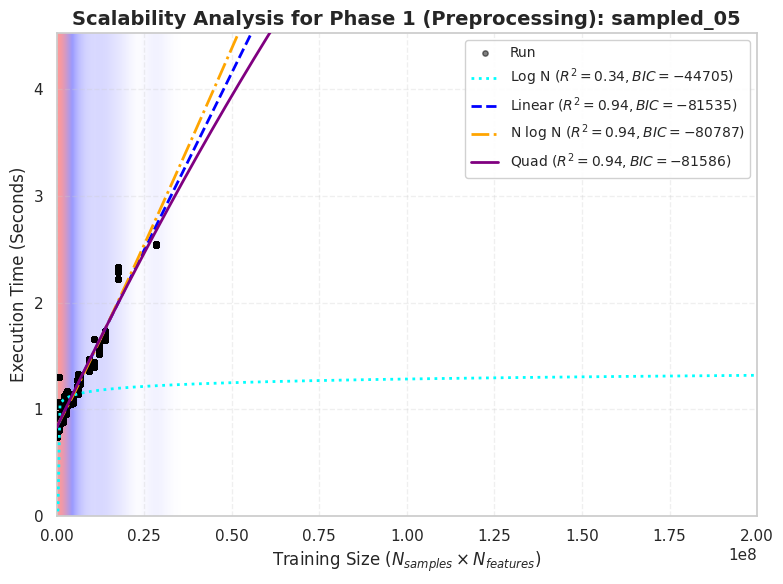

Saved: scalability_1_preprocessing_sampled_05.png and scalability_1_preprocessing_sampled_05.pdf


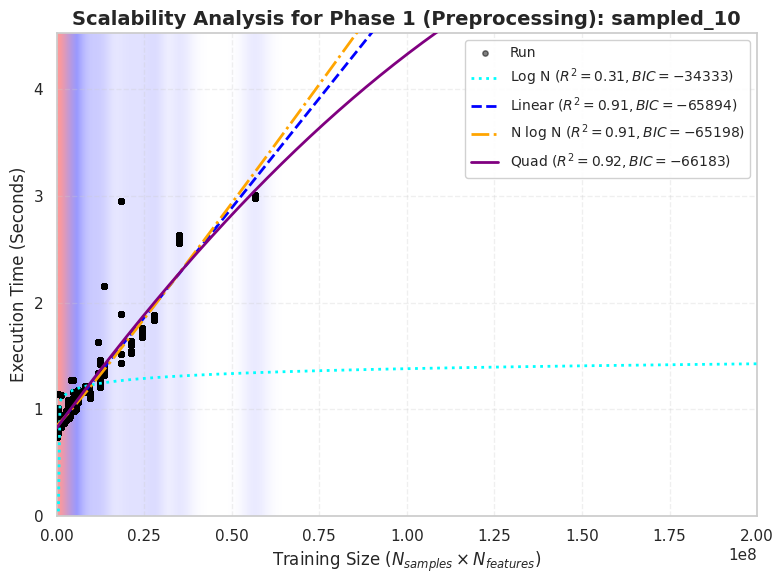

Saved: scalability_1_preprocessing_sampled_10.png and scalability_1_preprocessing_sampled_10.pdf


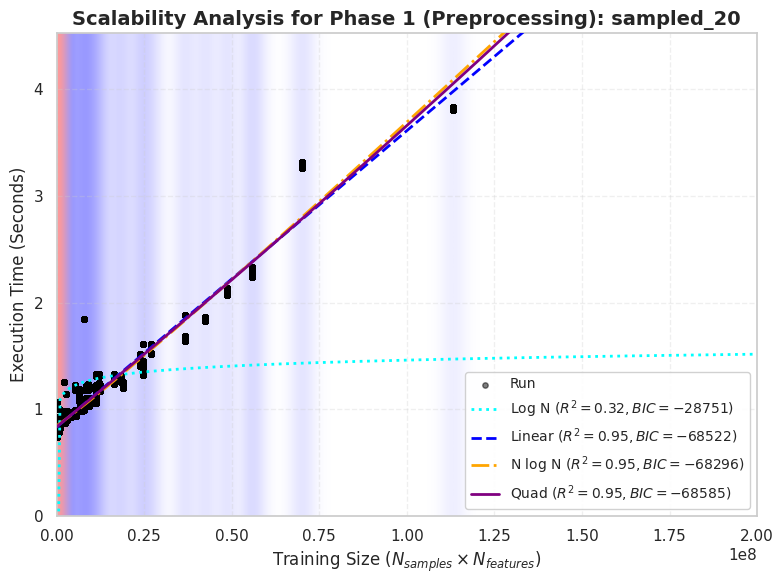

Saved: scalability_1_preprocessing_sampled_20.png and scalability_1_preprocessing_sampled_20.pdf


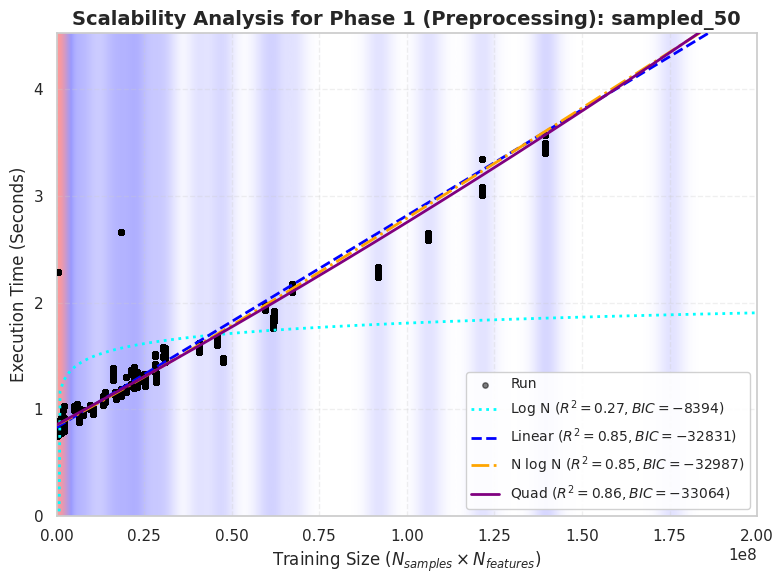

Saved: scalability_1_preprocessing_sampled_50.png and scalability_1_preprocessing_sampled_50.pdf


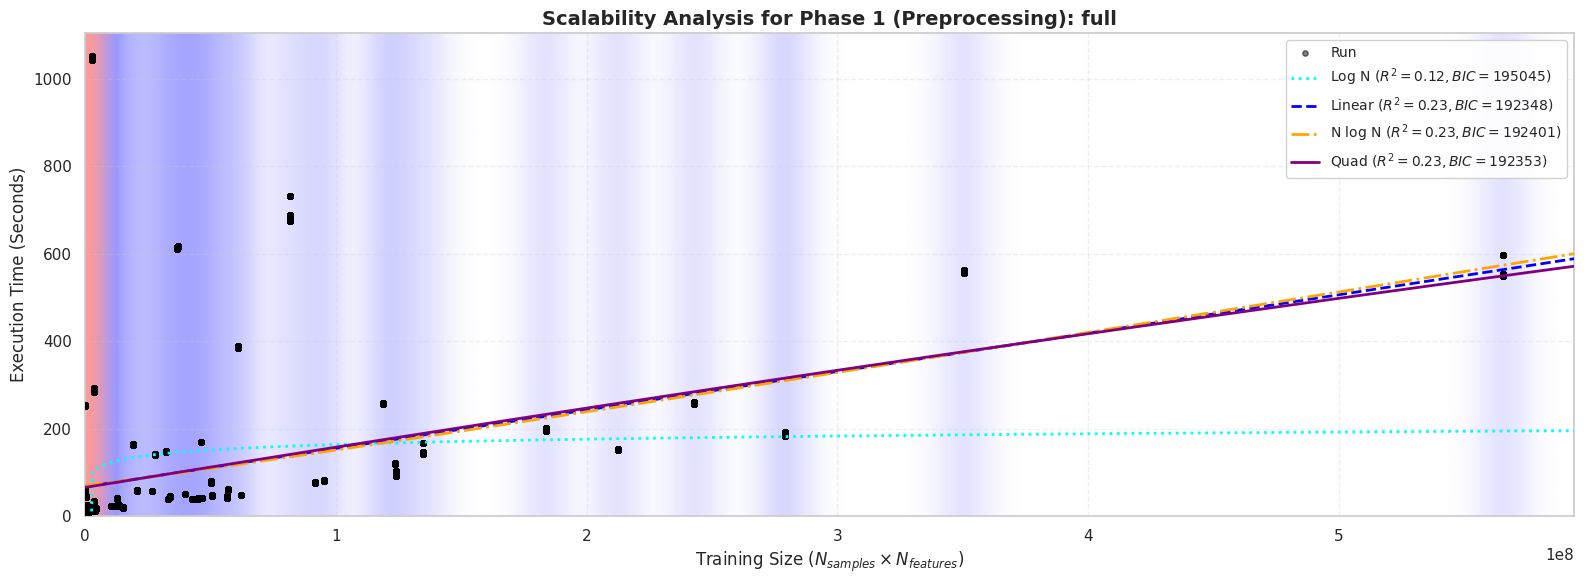

Saved: scalability_1_preprocessing_full.png and scalability_1_preprocessing_full.pdf


In [18]:
plot_scalability_individual_files(preprocessing_df, '1_preprocessing', 'total_duration_sec')

# Phase 2: Complexity

In [19]:
import os
import json
import pandas as pd

COMPLEXITY_ROOT_DIR = "../../2025-11-17/Output_Zip_v4_Complexity_v3"
fractions_to_exclude = []#'sampled_25', 'sampled_50']
current_fraction_order = [f for f in fraction_order if f not in fractions_to_exclude]

In [20]:
# --- 2. Load and Filter in one pass ---
complexity_rows = []

for dataset_id in os.listdir(COMPLEXITY_ROOT_DIR):
    if '.csv' in dataset_id: continue
    
    seed_parent_folder = os.path.join(COMPLEXITY_ROOT_DIR, dataset_id, 'Multiclass')
    if not os.path.exists(seed_parent_folder): continue

    for seed in os.listdir(seed_parent_folder):
        frac_parent_folder = os.path.join(seed_parent_folder, seed)
        for frac in os.listdir(frac_parent_folder):
            
            # Skip excluded fractions immediately
            if frac in fractions_to_exclude:
                continue
                
            json_filename = os.path.join(frac_parent_folder, frac, f'{dataset_id}_X_y.complexity.json')
            
            if os.path.exists(json_filename):
                with open(json_filename, 'r', encoding='utf-8') as f:
                    metadata = json.load(f)
                
                # Initialize row
                row = {'dataset_name': dataset_id, 'fraction': frac, 'seed': seed}
                
                # Flatten execution stats
                stats = metadata.get('execution_stats', {})
                for stage_name, stage_metrics in stats.items():
                    if stage_name.endswith('_end'):
                        for metric_name, metric_value in stage_metrics.items():
                            row[f"{stage_name}__{metric_name}"] = metric_value

                shapes = hyperdata["preprocessing"][dataset_id][frac][seed]['shapes'].copy()
                for shape_name, shape_value in shapes.items():
                    # print(dataset_id, frac, seed, shape_name, shape_value)
                    row[f"shapes__{shape_name}"] = shape_value

                complexity_rows.append(row)

In [21]:
# --- 3. Create DataFrame and Set Types ---
complexity_df = pd.DataFrame(complexity_rows)

# Cast to categorical (fixes the .cat Attribute error and the x-axis empty ticks)
complexity_df['fraction'] = pd.Categorical(
    complexity_df['fraction'], 
    categories=current_fraction_order, 
    ordered=True
)

In [22]:
complexity_df[complexity_df['fraction'] == 'full']

,dataset_name,fraction,seed,compute_anova_f_complexity_end__duration_sec,compute_anova_f_complexity_end__cpu_raw_peak,compute_anova_f_complexity_end__cpu_raw_avg,compute_anova_f_complexity_end__cpu_norm_peak,compute_anova_f_complexity_end__cpu_norm_avg,compute_anova_f_complexity_end__ram_peak_mb,compute_anova_f_complexity_end__ram_avg_mb,...,compute_mahalanobis_class_distance_end__gpu_util_avg,shapes__n_rows_train,shapes__n_rows_val,shapes__n_rows_test,shapes__n_rows_total,shapes__n_cols,shapes__n_cells_train,shapes__n_cells_val,shapes__n_cells_test,shapes__n_cells_total
3,BoT_IoT_Macro,full,seed_53,0.13,109.6,89.65,3.42,2.80,1475.47,1475.47,...,30.0,1747840,582613,582614,2913067,21,36704640,12234873,12234894,61174407
9,BoT_IoT_Macro,full,seed_23,0.14,99.4,84.50,3.11,2.64,1475.51,1475.51,...,80.0,1747840,582613,582614,2913067,21,36704640,12234873,12234894,61174407
15,BoT_IoT_Macro,full,seed_37,0.14,99.1,89.40,3.10,2.79,1475.39,1475.39,...,63.0,1747840,582613,582614,2913067,21,36704640,12234873,12234894,61174407
21,BoT_IoT_Macro,full,seed_89,0.14,89.6,89.55,2.80,2.80,1475.47,1475.47,...,53.0,1747840,582613,582614,2913067,21,36704640,12234873,12234894,61174407
27,BoT_IoT_Macro,full,seed_17,0.13,79.3,79.30,2.48,2.48,1475.52,1475.52,...,42.0,1747840,582613,582614,2913067,21,36704640,12234873,12234894,61174407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,ToN_IoT_IoT_Garage_Door,full,seed_53,0.03,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,16,1,1,18,3,48,3,3,54
2169,ToN_IoT_IoT_Garage_Door,full,seed_23,0.04,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,16,1,1,18,3,48,3,3,54
2175,ToN_IoT_IoT_Garage_Door,full,seed_37,0.04,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,16,1,1,18,3,48,3,3,54
2181,ToN_IoT_IoT_Garage_Door,full,seed_89,0.04,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,16,1,1,18,3,48,3,3,54


In [23]:
# --- 4. Aggregations ---

# CPU
cpu_cols = [c for c in complexity_df.columns if '__cpu_raw_peak' in c]
complexity_df['complexity_cpu_peak_max'] = complexity_df[cpu_cols].max(axis=1)

# RAM
ram_cols = [c for c in complexity_df.columns if '__ram_peak_mb' in c]
complexity_df['complexity_ram_peak_mb'] = complexity_df[ram_cols].max(axis=1)

# GPU
gpu_cols = [c for c in complexity_df.columns if '__gpu_util_peak' in c]
complexity_df['complexity_gpu_peak_max'] = complexity_df[gpu_cols].max(axis=1)

# VRAM
vram_cols = [c for c in complexity_df.columns if '__vram_peak_mb' in c]
complexity_df['complexity_vram_peak_mb'] = complexity_df[vram_cols].max(axis=1)

# Duration
dur_cols = [c for c in complexity_df.columns if '__duration_sec' in c]
complexity_df['complexity_duration_sec'] = complexity_df[dur_cols].sum(axis=1)

# --- 5. CLEANING: Remove Failed Runs ---
# valid_run = (RAM > 0) AND (Duration > 0)
# We do NOT filter on GPU because 0 GPU usage is a valid scientific finding.
complexity_df = complexity_df[
    (complexity_df['complexity_ram_peak_mb'] > 0) & 
    (complexity_df['complexity_duration_sec'] > 0)
].copy()

# Optional: Print how many rows were dropped
print(f"Remaining valid rows: {len(complexity_df)}")

Remaining valid rows: 2073


In [24]:
# --- 1. Define Scale-Specific Ticks ---

# CPU: 1 to 64 Cores
cpu_cores = [1, 2]
cpu_ticks = [c * 100 for c in cpu_cores]
cpu_labels = [f'{c} Cores' for c in cpu_cores]

# RAM: 1GB to 4GB
ram_gb = [1, 1.5]
ram_ticks = [g * 1024 for g in ram_gb]
ram_labels = [f'{g}GB' for g in ram_gb]

# VRAM: 256MB to 2GB
vram_gb = [0.25, 0.5, 1, 2, 4, 8, 16, 32]
vram_ticks = [g * 1024 for g in vram_gb]
vram_labels = [f'{int(g*1024)}MB' if g < 1 else f'{g}GB' for g in vram_gb]

# Duration: 1s to 2h (Log scale)
time_vals = [1, 10, 60]
time_labels = ['1s', '10s', '1m']

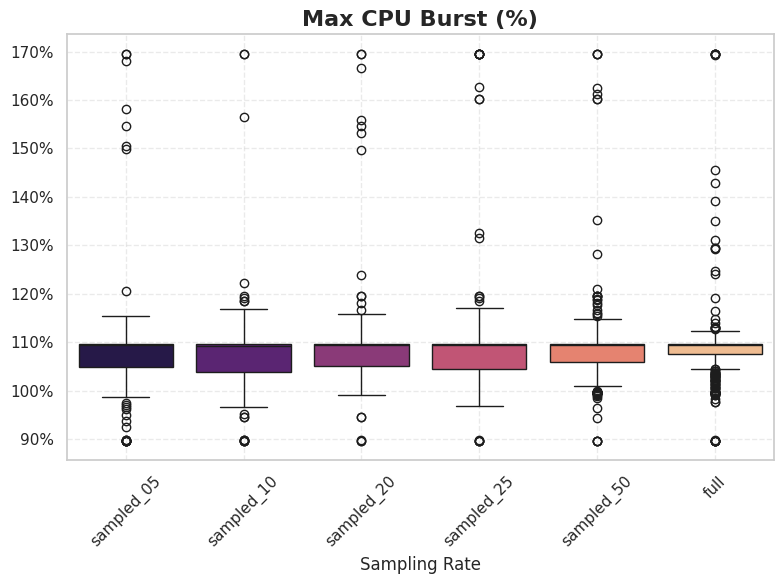

Generated phase_2_boxplot_complexity_cpu_peak_max.pdf


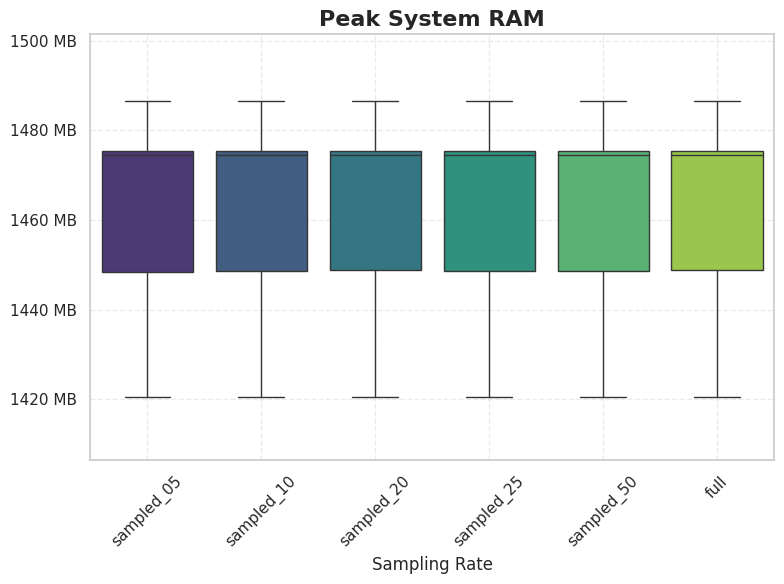

Generated phase_2_boxplot_complexity_ram_peak_mb.pdf


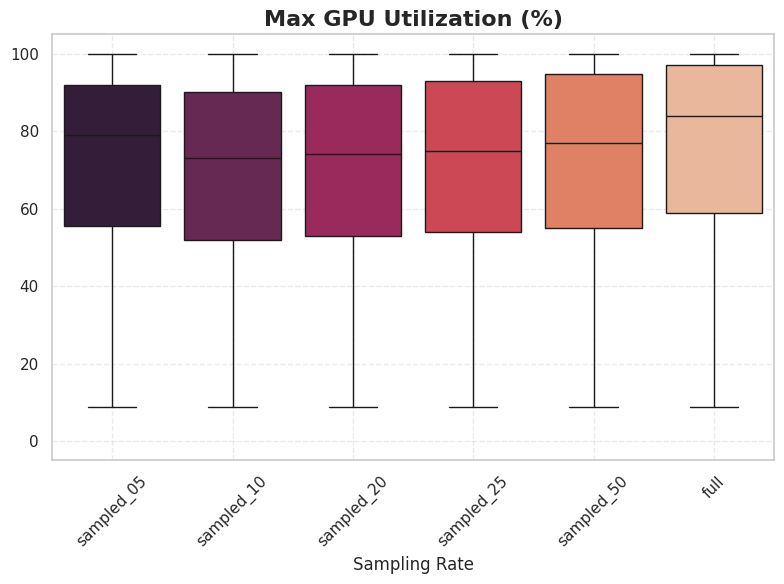

Generated phase_2_boxplot_complexity_gpu_peak_max.pdf


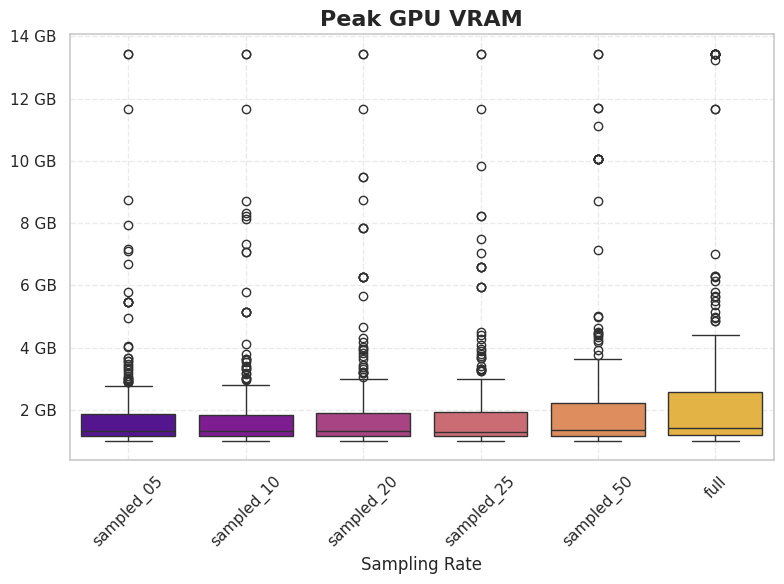

Generated phase_2_boxplot_complexity_vram_peak_mb.pdf


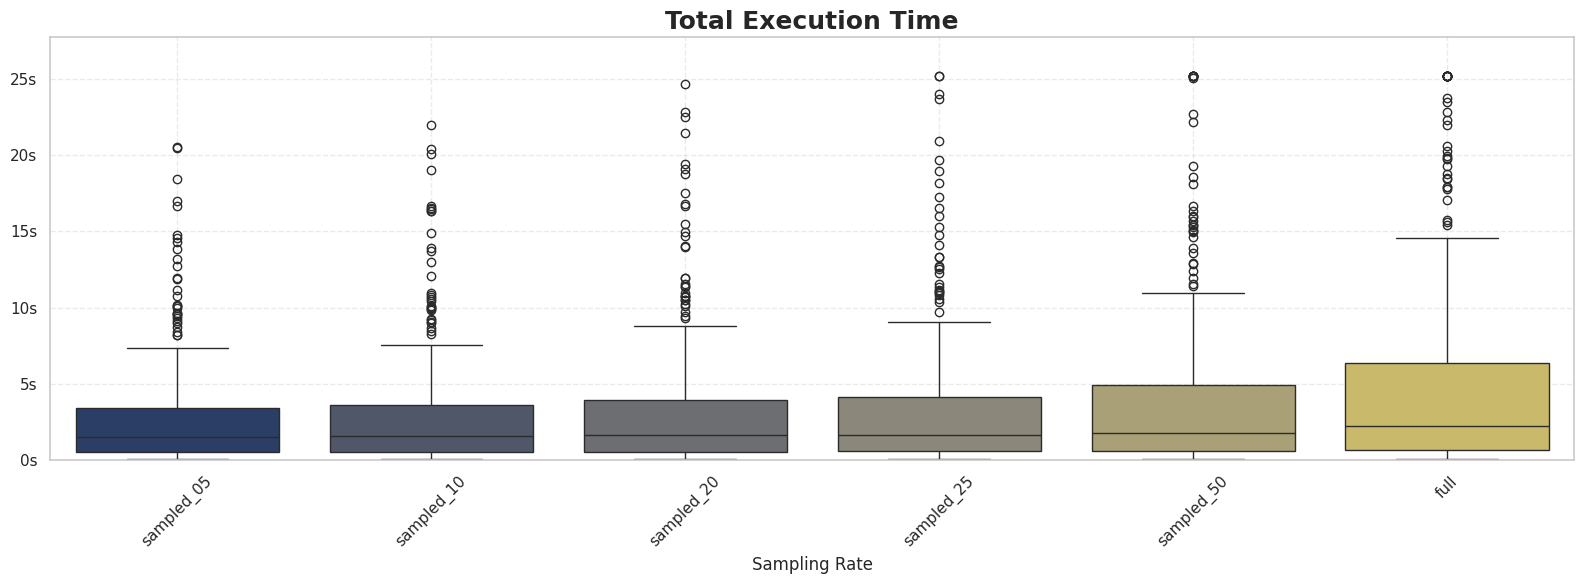

Generated phase_2_boxplot_complexity_duration_sec.pdf


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- 1. Configurations ---
# (column_name, title, palette, ticks, labels, log_base)
# Note: ticks/labels/log_base are largely ignored now as we use dynamic linear formatting
plot_configs = [
    ('complexity_cpu_peak_max', 'Max CPU Burst (%)', 'magma', None, None, 2),
    ('complexity_ram_peak_mb', 'Peak System RAM', 'viridis', None, None, 2),
    ('complexity_gpu_peak_max', 'Max GPU Utilization (%)', 'rocket', None, None, None),
    ('complexity_vram_peak_mb', 'Peak GPU VRAM', 'plasma', None, None, 2),
    ('complexity_duration_sec', 'Total Execution Time', 'cividis', None, None, 10)
]

sns.set_theme(style="whitegrid")

# --- 2. Generation Loop ---
for col, title, pal, ticks, labels, log_base in plot_configs:
    
    # 1. FILTERING: Remove valid errors (0s)
    clean_data = complexity_df[complexity_df[col] > 0].copy()

    # 2. WINSORIZATION (Soft Clipping)
    # Clip the bottom 1% and top 1% to handle extreme outliers gracefully
    low_limit = clean_data[col].quantile(0.01)
    high_limit = clean_data[col].quantile(0.99)
    clean_data[col] = clean_data[col].clip(lower=low_limit, upper=high_limit)
    
    # Check if this is the duration plot to double the width
    width = 16 if 'duration' in col else 8
    plt.figure(figsize=(width, 6))
    
    # 3. BOX PLOT
    ax = sns.boxplot(
        data=clean_data,
        x='fraction',
        y=col,
        order=current_fraction_order,
        hue='fraction',
        palette=pal,
        legend=False,
        showfliers=True # Keep outliers visible (now that they are clipped)
    )
    
    # Standard Formatting
    plt.title(title, fontweight='bold', fontsize=18 if width > 8 else 16)
    plt.xlabel("Sampling Rate", fontsize=12)
    plt.ylabel("")
    plt.xticks(rotation=45)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)

    # --- SCALING LOGIC ---
    
    # 1. VRAM (Check first!)
    if 'vram' in col:
        plt.yscale('linear')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1024:.0f} GB'))
        
    # 2. GPU Utilization
    elif 'gpu_peak_max' in col:
        plt.ylim(-5, 105)

    # 3. CPU (Linear %)
    elif 'cpu' in col:
        plt.yscale('linear')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))

    # 4. RAM (System)
    elif 'ram_peak_mb' in col:
        plt.yscale('linear')
        # Zoom to the clipped range
        plt.ylim(low_limit * 0.99, high_limit * 1.01)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)} MB'))
        
    # 5. Time (Duration)
    elif 'duration' in col:
        plt.yscale('linear')
        y_max = clean_data[col].max() * 1.1 
        plt.ylim(0, y_max)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}s'))
    
    plt.tight_layout()
    
    # Save as separate PDF
    filename = f"phase_2_boxplot_{col}.pdf"
    plt.savefig(filename, format='pdf', dpi=300)
    plt.show()
    plt.close()
    
    print(f"Generated {filename}")

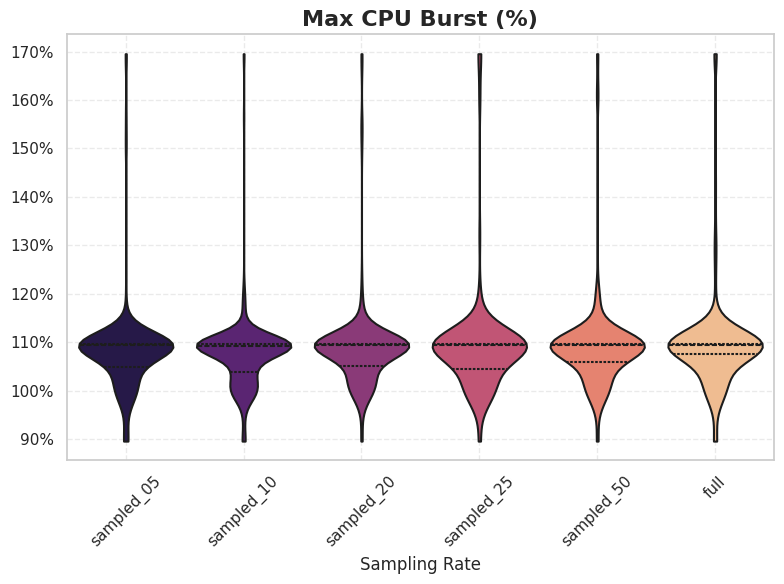

Generated phase_2_violin_complexity_cpu_peak_max.pdf


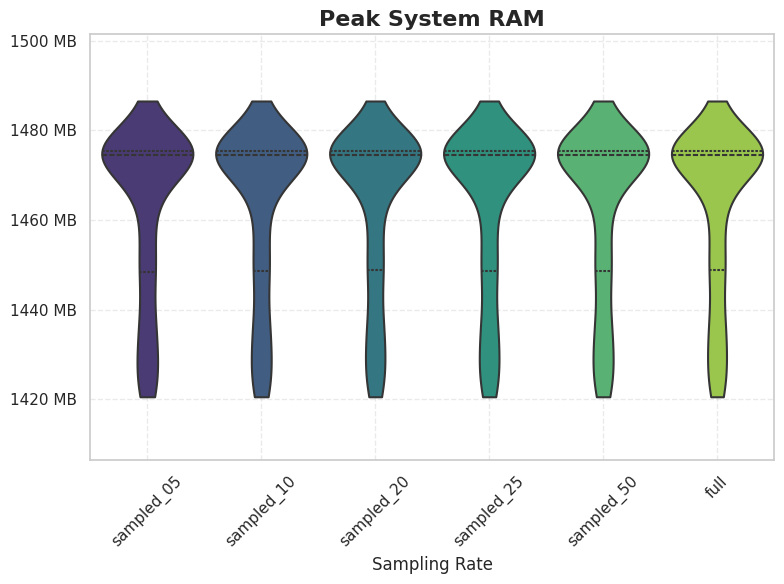

Generated phase_2_violin_complexity_ram_peak_mb.pdf


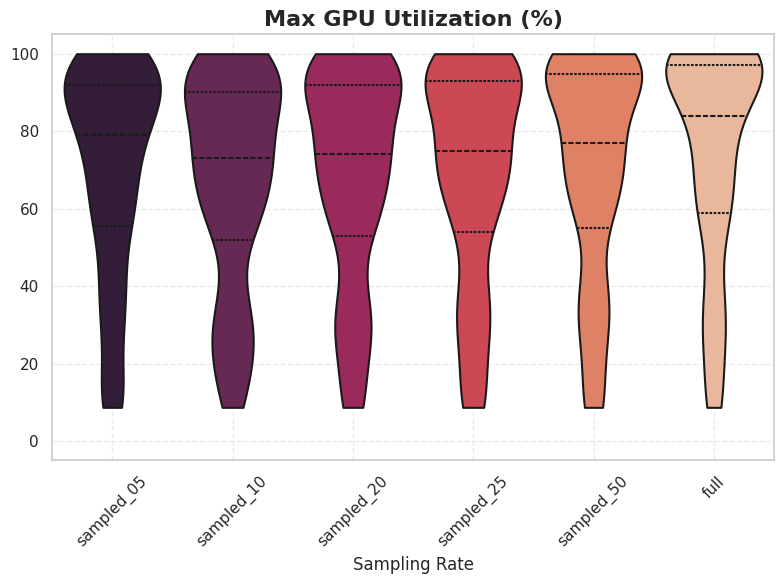

Generated phase_2_violin_complexity_gpu_peak_max.pdf


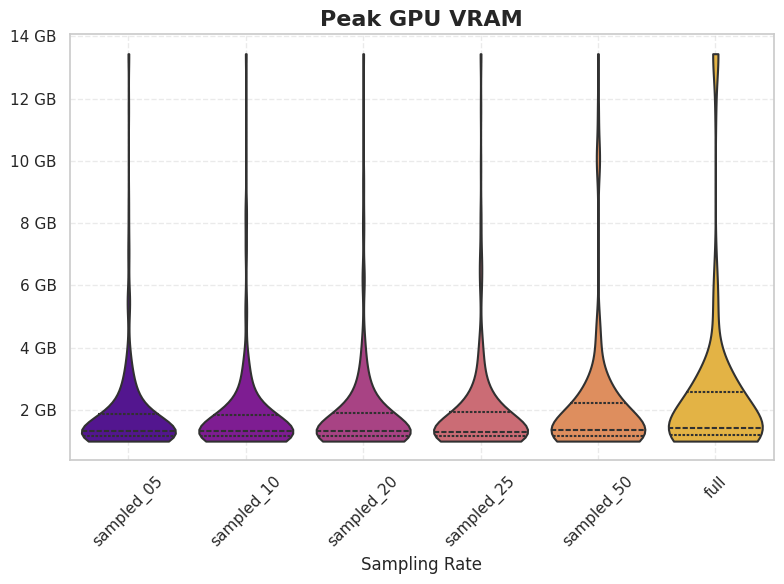

Generated phase_2_violin_complexity_vram_peak_mb.pdf


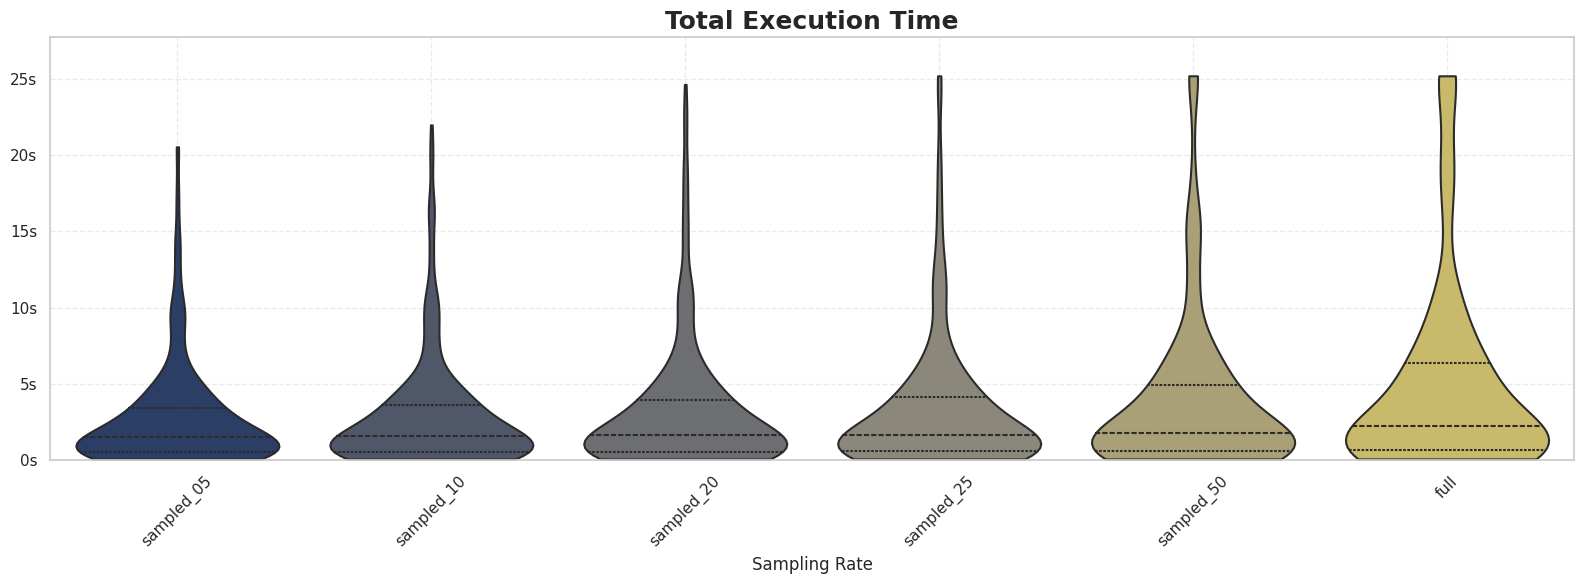

Generated phase_2_violin_complexity_duration_sec.pdf


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- 1. Configurations ---
# (column_name, title, palette, ticks, labels, log_base)
plot_configs = [
    ('complexity_cpu_peak_max', 'Max CPU Burst (%)', 'magma', None, None, 2),
    ('complexity_ram_peak_mb', 'Peak System RAM', 'viridis', None, None, 2),
    ('complexity_gpu_peak_max', 'Max GPU Utilization (%)', 'rocket', None, None, None),
    ('complexity_vram_peak_mb', 'Peak GPU VRAM', 'plasma', None, None, 2),
    ('complexity_duration_sec', 'Total Execution Time', 'cividis', None, None, 10)
]

sns.set_theme(style="whitegrid")

# --- 2. Generation Loop ---
for col, title, pal, ticks, labels, log_base in plot_configs:
    
    # 1. FILTERING: Remove valid errors (0s)
    clean_data = complexity_df[complexity_df[col] > 0].copy()

    # 2. WINSORIZATION
    # Soft clip to keep the distribution shape reasonable
    low_limit = clean_data[col].quantile(0.01)
    high_limit = clean_data[col].quantile(0.99)
    clean_data[col] = clean_data[col].clip(lower=low_limit, upper=high_limit)
    
    # Check if this is the duration plot to double the width
    width = 16 if 'duration' in col else 8
    plt.figure(figsize=(width, 6))
    
    # 3. VIOLIN PLOT
    ax = sns.violinplot(
        data=clean_data,
        x='fraction',
        y=col,
        order=current_fraction_order,
        hue='fraction',
        palette=pal,
        legend=False,
        inner='quartile', # Draw median and quartiles
        linewidth=1.5,
        cut=0             # Prevent tails from going to infinity/negative
    )
    
    # Standard Formatting
    plt.title(title, fontweight='bold', fontsize=18 if width > 8 else 16)
    plt.xlabel("Sampling Rate", fontsize=12)
    plt.ylabel("")
    plt.xticks(rotation=45)
    plt.grid(True, which='both', linestyle='--', alpha=0.4)

    # --- SCALING LOGIC (Identical to Boxplots) ---
    
    # 1. VRAM (Check first!)
    if 'vram' in col:
        plt.yscale('linear')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1024:.0f} GB'))
        
    # 2. GPU Utilization
    elif 'gpu_peak_max' in col:
        plt.ylim(-5, 105)

    # 3. CPU (Linear %)
    elif 'cpu' in col:
        plt.yscale('linear')
        # plt.ylim(75, 180) # Optional: unlock this if violin tails get cut off
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))

    # 4. RAM (System)
    elif 'ram_peak_mb' in col:
        plt.yscale('linear')
        # Zoom to the clipped range
        plt.ylim(low_limit * 0.99, high_limit * 1.01)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)} MB'))
        
    # 5. Time (Duration)
    elif 'duration' in col:
        plt.yscale('linear')
        y_max = clean_data[col].max() * 1.1 
        plt.ylim(0, y_max)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}s'))
    
    plt.tight_layout()
    
    # Save as separate PDF
    filename = f"phase_2_violin_{col}.pdf"
    plt.savefig(filename, format='pdf', dpi=300)
    plt.show()
    plt.close()
    
    print(f"Generated {filename}")

In [27]:
# --- Configuration for the Table ---
# We focus on the median values for a robust comparison
table_cols = {
    'complexity_cpu_peak_max': 'CPU (%)',
    'complexity_ram_peak_mb': 'RAM (MB)',
    'complexity_vram_peak_mb': 'VRAM (GB)',  # converting to GB to match plot
    'complexity_duration_sec': 'Time (s)'
}

# 1. Group by Fraction and Calculate Median
summary = complexity_df.groupby('fraction')[list(table_cols.keys())].median()

# 2. Rename Columns
summary = summary.rename(columns=table_cols)

# 3. Unit Conversions (Matching your plots)
# CPU is already in % (e.g., 100.0)
# RAM is already in MB
# VRAM: MB -> GB
summary['VRAM (GB)'] = summary['VRAM (GB)'] / 1024
# Time: Seconds (already correct)

# 4. Calculate Speedup (Efficiency)
# How many times faster is this fraction compared to 'full'?
full_time = summary.loc['full', 'Time (s)']
summary['Speedup (x)'] = full_time / summary['Time (s)']

# 5. Format for LaTeX
# Rounding for cleanliness
summary['CPU (%)'] = summary['CPU (%)'].round(2)
summary['RAM (MB)'] = summary['RAM (MB)'].round(2).astype(int)
summary['VRAM (GB)'] = summary['VRAM (GB)'].round(2)
summary['Time (s)'] = summary['Time (s)'].round(2)
summary['Speedup (x)'] = summary['Speedup (x)'].round(2)

# Reorder for logical flow
final_table = summary[['RAM (MB)', 'CPU (%)', 'VRAM (GB)', 'Time (s)', 'Speedup (x)']]

# 6. Generate LaTeX
print("-" * 30)
print("LaTeX Table Code:")
print("-" * 30)
print(final_table.to_latex(float_format="%.1f"))
print("-" * 30)

# Display readable version
display(final_table)

------------------------------
LaTeX Table Code:
------------------------------
\begin{tabular}{lrrrrr}
\toprule
 & RAM (MB) & CPU (%) & VRAM (GB) & Time (s) & Speedup (x) \\
fraction &  &  &  &  &  \\
\midrule
sampled_05 & 1474 & 109.4 & 1.3 & 1.5 & 1.5 \\
sampled_10 & 1474 & 109.3 & 1.3 & 1.6 & 1.4 \\
sampled_20 & 1474 & 109.4 & 1.3 & 1.7 & 1.3 \\
sampled_25 & 1474 & 109.4 & 1.3 & 1.7 & 1.4 \\
sampled_50 & 1474 & 109.4 & 1.3 & 1.8 & 1.3 \\
full & 1474 & 109.5 & 1.4 & 2.3 & 1.0 \\
\bottomrule
\end{tabular}

------------------------------


/tmp/ipykernel_23756/3475558228.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = complexity_df.groupby('fraction')[list(table_cols.keys())].median()


,RAM (MB),CPU (%),VRAM (GB),Time (s),Speedup (x)
fraction,,,,,
sampled_05,1474,109.4,1.28,1.54,1.46
sampled_10,1474,109.3,1.28,1.62,1.40
sampled_20,1474,109.4,1.28,1.68,1.34
sampled_25,1474,109.4,1.28,1.67,1.35
sampled_50,1474,109.4,1.31,1.78,1.27
full,1474,109.5,1.41,2.26,1.00


In [28]:
for i in complexity_df.columns:
    print(i)

dataset_name
fraction
seed
compute_anova_f_complexity_end__duration_sec
compute_anova_f_complexity_end__cpu_raw_peak
compute_anova_f_complexity_end__cpu_raw_avg
compute_anova_f_complexity_end__cpu_norm_peak
compute_anova_f_complexity_end__cpu_norm_avg
compute_anova_f_complexity_end__ram_peak_mb
compute_anova_f_complexity_end__ram_avg_mb
compute_anova_f_complexity_end__vram_peak_mb
compute_anova_f_complexity_end__vram_avg_mb
compute_anova_f_complexity_end__gpu_util_peak
compute_anova_f_complexity_end__gpu_util_avg
compute_mutual_info_complexity_end__duration_sec
compute_mutual_info_complexity_end__cpu_raw_peak
compute_mutual_info_complexity_end__cpu_raw_avg
compute_mutual_info_complexity_end__cpu_norm_peak
compute_mutual_info_complexity_end__cpu_norm_avg
compute_mutual_info_complexity_end__ram_peak_mb
compute_mutual_info_complexity_end__ram_avg_mb
compute_mutual_info_complexity_end__vram_peak_mb
compute_mutual_info_complexity_end__vram_avg_mb
compute_mutual_info_complexity_end__gpu_util

--- Generating Individual Scalability Plots (PNG & PDF) ---


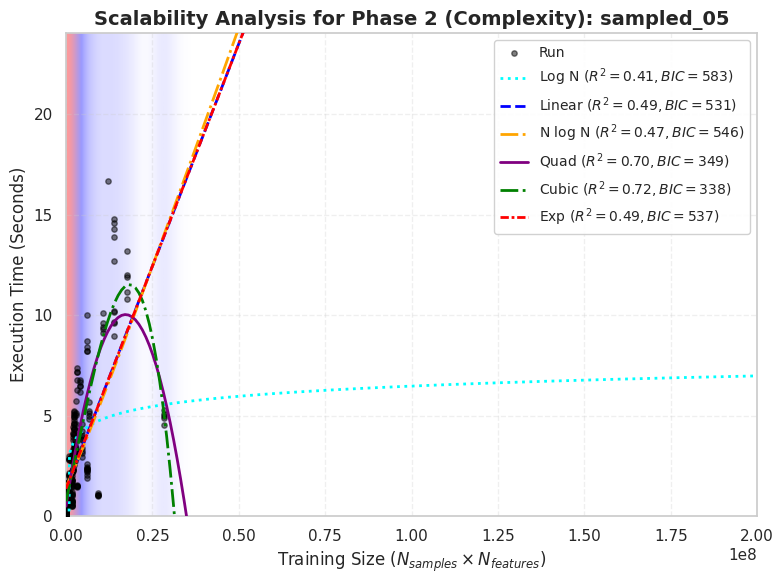

Saved: scalability_2_complexity_sampled_05.png and scalability_2_complexity_sampled_05.pdf


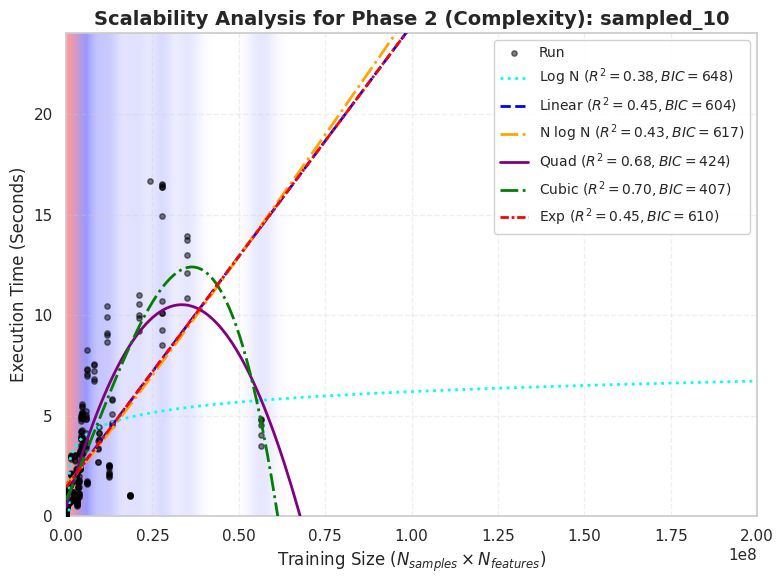

Saved: scalability_2_complexity_sampled_10.png and scalability_2_complexity_sampled_10.pdf


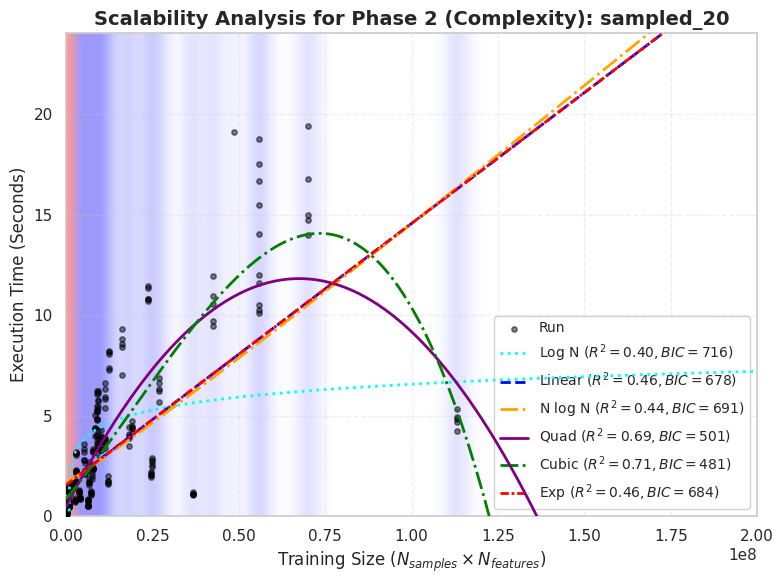

Saved: scalability_2_complexity_sampled_20.png and scalability_2_complexity_sampled_20.pdf


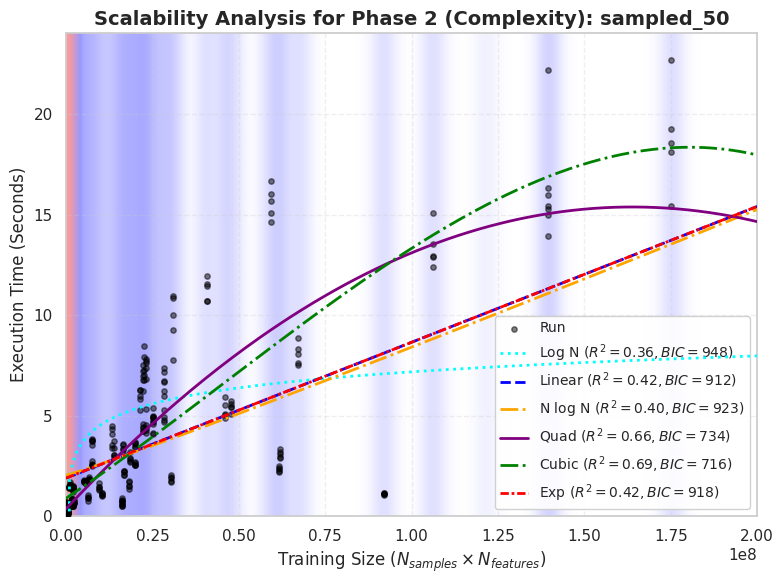

Saved: scalability_2_complexity_sampled_50.png and scalability_2_complexity_sampled_50.pdf


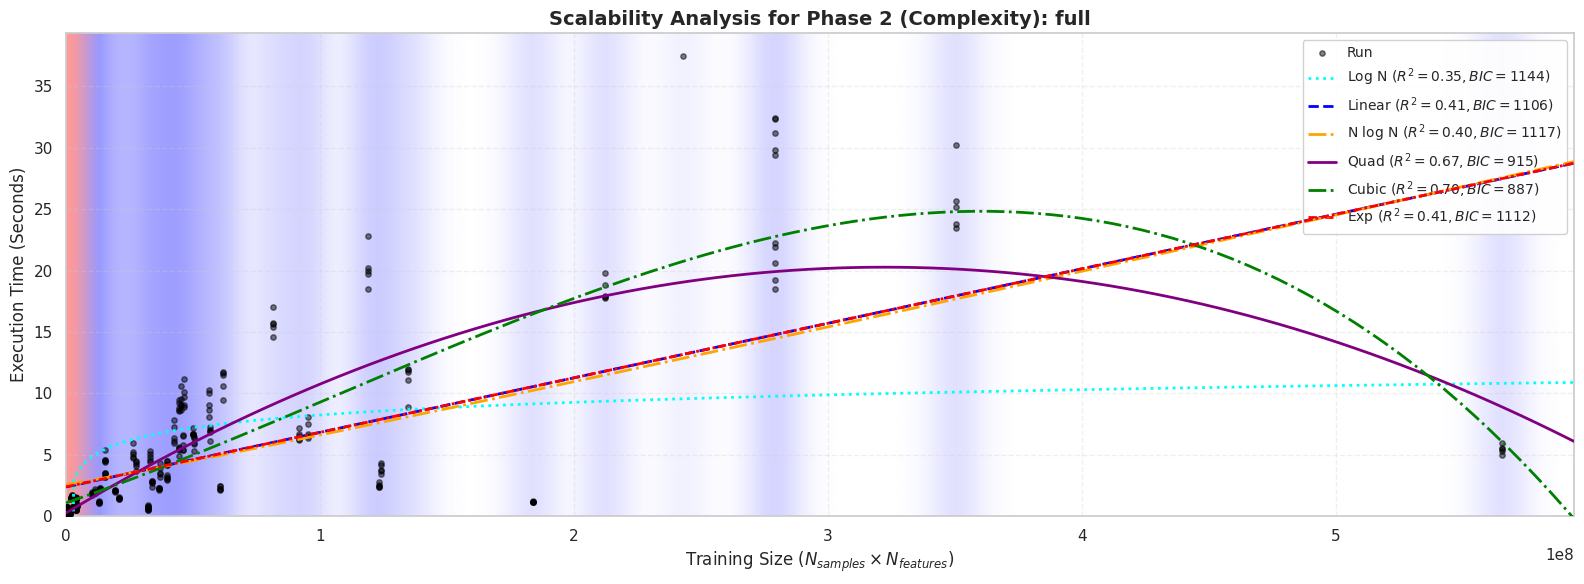

Saved: scalability_2_complexity_full.png and scalability_2_complexity_full.pdf


In [29]:
plot_scalability_individual_files(complexity_df, '2_complexity', 'complexity_duration_sec')

In [30]:
# 1. Identify all metric columns (the ones we created with stage__metric)
metric_cols = [c for c in df.columns if '__' in c]

# 2. Filter that list to keep only those with NO NaNs
plottable_metrics = [col for col in metric_cols if df[col].notna().all()]

print(f"Total metrics: {len(metric_cols)}")
print(f"Metrics without NaNs (Safe for plotting): {len(plottable_metrics)}")

# 3. If you want to see which ones were dropped:
dropped_metrics = list(set(metric_cols) - set(plottable_metrics))
print(f"Dropped due to NaNs: {dropped_metrics}")

NameError: name 'df' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through the first 5 clean metrics as an example
for metric in plottable_metrics:
    plt.figure(figsize=(15, 6))
    
    sns.lineplot(
        data=df, 
        x='dataset_id', 
        y=metric, 
        hue='fraction', 
        marker='o'
    )
    
    plt.xticks(range(1, 74), rotation=90, fontsize=7)
    plt.title(f"Comparison of {metric}")
    plt.tight_layout()
    
    # Save each plot automatically
    file_name = f"profiling/plot_{metric.replace('__', '_')}.png"
    plt.savefig(file_name)
    plt.close() # Close to save memory

In [ ]:
# 1. Calculate Total Peak RAM across all stages
ram_cols = [c for c in df.columns if '__ram_peak_mb' in c]
df['total_ram_peak_mb'] = df[ram_cols].max(axis=1)

# 2. Calculate Total Duration
duration_cols = [c for c in df.columns if '__duration_sec' in c]
df['total_duration_sec'] = df[duration_cols].sum(axis=1)

# 3. Calculate Average CPU Peak (or Max Peak)
cpu_cols = [c for c in df.columns if '__cpu_raw_peak' in c]
df['total_cpu_peak_max'] = df[cpu_cols].max(axis=1)

In [ ]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Set logical order
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

# Use the new AGGREGATED column here
# Change 'total_ram_peak_mb' to 'total_cpu_peak_max' to see the CPU version
sns.boxplot(
    data=df, 
    x='fraction', 
    y='total_ram_peak_mb', 
    order=fraction_order, 
    palette="viridis",
    showfliers=True  # Keep the outliers visible
)

# 3. SCALE IMPROVEMENT: Log scale is essential for RAM
# This prevents the 'full' dataset from squashing the 'sampled' bars to 0
plt.yscale('log')

# 4. FORMATTING
plt.title("Total Pipeline Resource Consumption: Sampling vs. Full Dataset", fontsize=15, pad=15)
plt.ylabel("Peak RAM (MB) - Log Scale", fontsize=12)
plt.xlabel("Sampling Rate", fontsize=12)
plt.grid(True, which="both", axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the fractions are in the correct logical order
fraction_order = ['sampled_05', 'sampled_10', 'sampled_20', 'sampled_25', 'sampled_50', 'full']

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plotting the RAM peak for the 'splitting' stage
sns.boxplot(
    data=df, 
    x='fraction', 
    y='profiling__ram_peak_mb', 
    order=fraction_order, 
    palette="magma"
)

plt.title("Peak RAM Usage Distribution: Sampling vs. Full Dataset (Splitting Stage)", fontsize=14)
plt.ylabel("Peak RAM (MB)")
plt.xlabel("Sampling Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("ram_peak_boxplot.png", dpi=300)
plt.show()